In [5]:
import pandas as pd
import json
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [1]:
pip install pandas sentence-transformers scikit-learn

In [8]:
df = pd.read_csv('tmdb_5000_movies.csv')
df = df[['overview', 'genres']].dropna()

def parse_genre(genre_str):
    genres = json.loads(genre_str)
    if len(genres) > 0:
        return genres[0]['name']
    return None

df['genre_label'] = df['genres'].apply(parse_genre)
df = df.dropna(subset=['genre_label'])

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X = model.encode(df['overview'].tolist(), show_progress_bar=True)
y = df['genre_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/150 [00:00<?, ?it/s]

LogisticRegression(max_iter=1000)

In [11]:
test_cases = [
    "A secret agent travels to London to stop a terrorist organization from detonating a bomb.", # Action
    "A group of friends goes to a cabin in the woods where a masked killer starts hunting them.", # Horror
    "Two clumsy roommates get into hilarious situations while trying to win a local talent show.", # Comedy
    "In the year 2150, humans live in underwater cities and fight for resources with giant robots.", # Sci-Fi

    "История о молодом человеке, который пытается наладить отношения с отцом после долгих лет разлуки.", # Drama
    "Команда супергероев объединяется, чтобы спасти галактику от древнего зла.", # Action/Adventure
    "Привидение в старинном замке пугает новых жильцов по ночам.", # Horror
    "Очень смешная история про говорящего кота и его ленивого хозяина.", # Comedy

    "The silence in the hallway was broken only by the sound of heavy breathing behind the door.", #Horror
    "Love is a battlefield, and Sarah was about to lose her heart in the middle of New York City.", #Romance/Drama
    "The discovery of a strange signal from Proxima Centauri changed everything for the crew of Aurora.", #Sci-Fi
    "Explosions rocked the city as the car chase moved toward the bridge at high speed." #Action
]

for text in test_cases:
    vec = model.encode([text])
    prediction = clf.predict(vec)[0]
    print(f"{text[:50]}...")
    print(f"ответ: {prediction}\n")

A secret agent travels to London to stop a terrori...
ответ: Action

A group of friends goes to a cabin in the woods wh...
ответ: Horror

Two clumsy roommates get into hilarious situations...
ответ: Comedy

In the year 2150, humans live in underwater cities...
ответ: Action

История о молодом человеке, который пытается налад...
ответ: Drama

Команда супергероев объединяется, чтобы спасти гал...
ответ: Adventure

Привидение в старинном замке пугает новых жильцов ...
ответ: Horror

Очень смешная история про говорящего кота и его ле...
ответ: Comedy

The silence in the hallway was broken only by the ...
ответ: Drama

Love is a battlefield, and Sarah was about to lose...
ответ: Drama

The discovery of a strange signal from Proxima Cen...
ответ: Science Fiction

Explosions rocked the city as the car chase moved ...
ответ: Action



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 precision    recall  f1-score   support

         Action       0.44      0.51      0.47       153
      Adventure       0.37      0.25      0.30        76
      Animation       0.29      0.30      0.29        20
         Comedy       0.48      0.63      0.55       203
          Crime       0.19      0.12      0.15        40
    Documentary       0.43      0.25      0.32        12
          Drama       0.48      0.56      0.52       232
         Family       0.00      0.00      0.00        13
        Fantasy       0.14      0.14      0.14        21
        History       0.00      0.00      0.00         5
         Horror       0.50      0.40      0.44        75
          Music       0.00      0.00      0.00         9
        Mystery       0.25      0.08      0.12        12
        Romance       0.00      0.00      0.00        21
Science Fiction       0.14      0.10      0.12        20
       Thriller       0.14      0.08      0.10        37
            War       0.00    

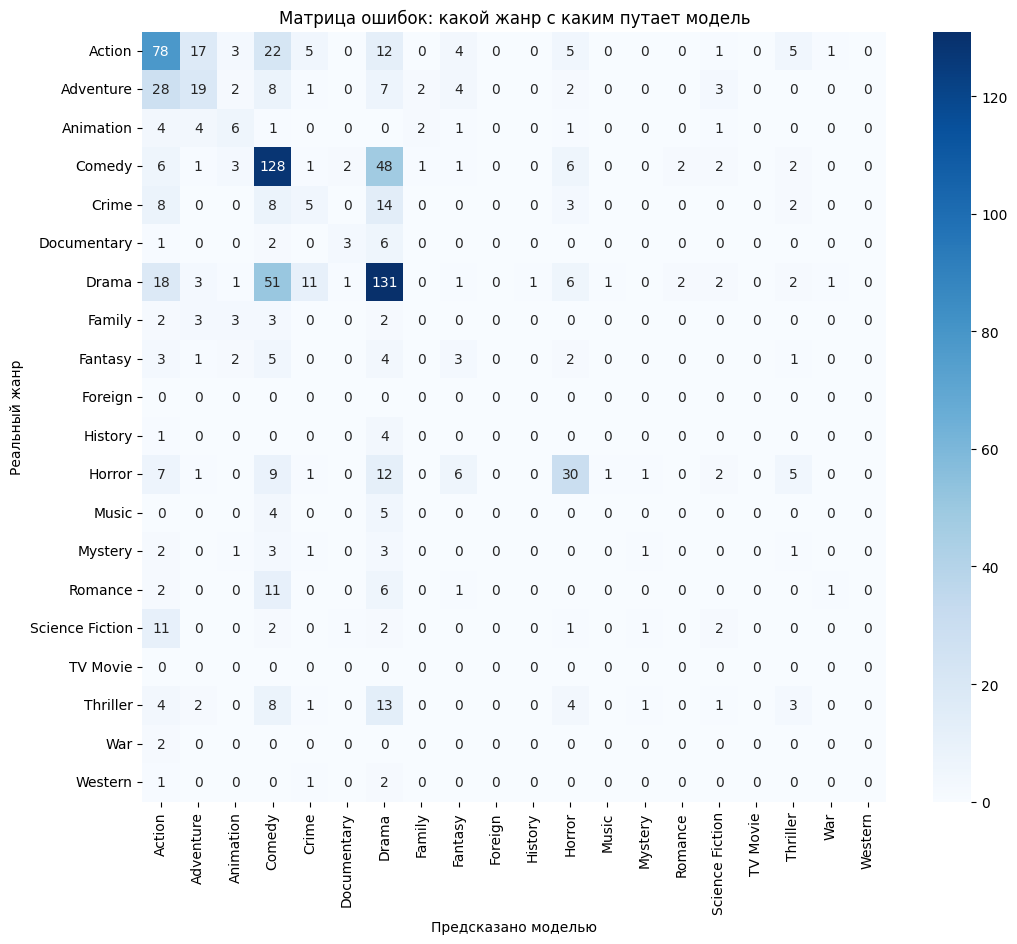

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=clf.classes_, yticklabels=clf.classes_, cmap='Blues')
plt.title('Матрица ошибок: какой жанр с каким путает модель')
plt.xlabel('Предсказано моделью')
plt.ylabel('Реальный жанр')
plt.show()

Модель путает Drama и Horror, Romance и Comedy, Drama и Action, и почему то очень сильно Drama и Comedy.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/150 [00:00<?, ?it/s]

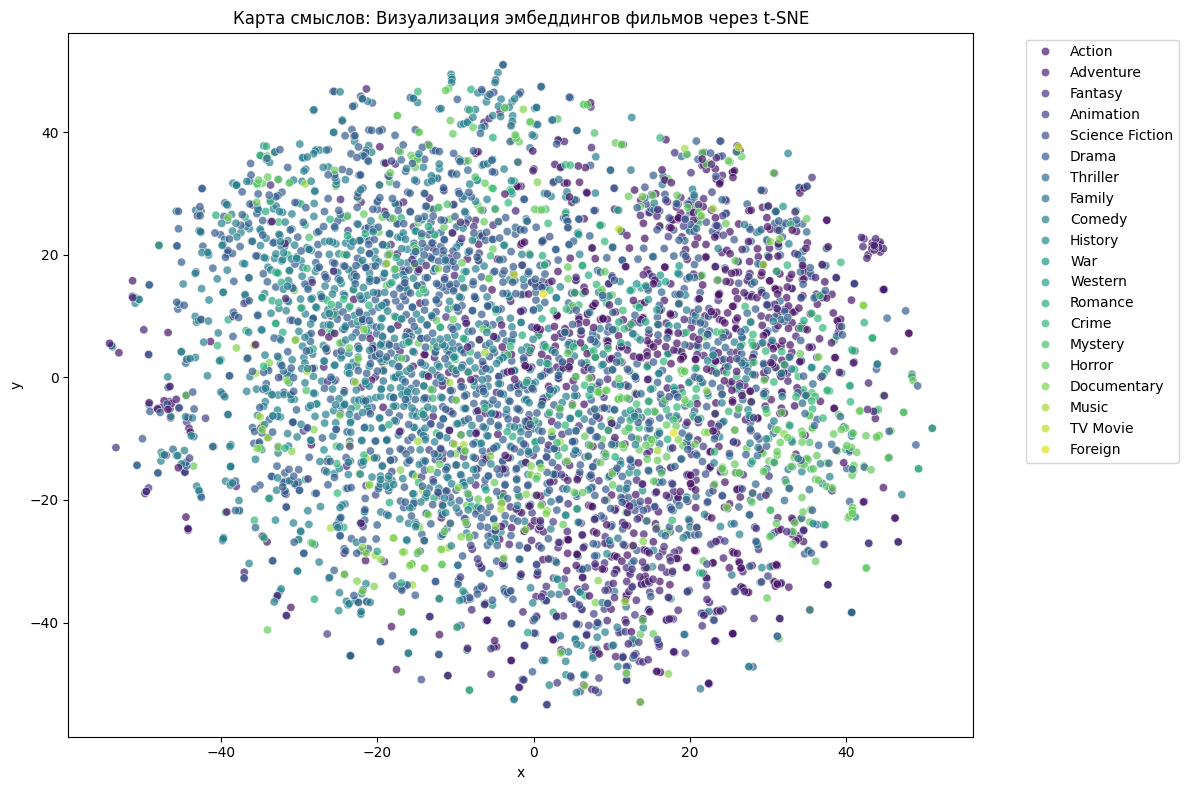

In [16]:
from sklearn.manifold import TSNE

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model.encode(df['overview'].tolist(), show_progress_bar=True)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))

tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': df['genre_label']
})

sns.scatterplot(data=tsne_df, x='x', y='y', hue='genre', palette='viridis', alpha=0.7)
plt.title('Карта смыслов: Визуализация эмбеддингов фильмов через t-SNE')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()